# Plot impact of population size

Consider the time of the MRCA of 2 individuals with a sequence length $L$, $k$ mutations and a mutation rate $\mu$ assuming the infinite site model.
The population size is modeled as a function of time $N(t)$. This gives the following posterior distribution of $t_{MRCA}$:
$$
P(t_{MRCA}|k) = \frac{P(k|t_{MRCA})\cdot P(t_{MRCA}|N)}{P(k)} \propto P(k|t_{MRCA})\cdot P(t_{MRCA}|N)
$$

with: 
$$
P(k|t_{MRCA}) = \frac{(2 \cdot \mu \cdot L \cdot t_{MRCA})^k}{k!} \, e^{-2 \mu L s}
$$ 
and:
$$
P(t_{MRCA}|N) = \frac{1}{N(t_{\text{present}} - t_{MRCA}) \cdot g} \cdot e^{- \int_0^{t_{MRCA}} \frac{1}{g \cdot N(t_{\text{present}} - s)} \, ds}
$$

Set generation time $g = 1$.


As a first step, assume constant population size $N(t) = N_0$.

In [ ]:
from math import exp, factorial
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance
from scipy.interpolate import interp1d

In [66]:
def likelihood_tMRCA_mutations(k_mut, mu, t_MRCA, L = 100):
    """
    Calculate the likelihood of observing k_mut mutations given a tMRCA and mutation rate.
    We only look at the tMRCA of two sequences sampled at the same time point.
    
    Parameters:
    k_mut (int): Number of mutations observed.
    mu (float): Mutation rate per base pair per generation.
    t_MRCA (float): calendar time to the most recent common ancestor, assume a generation time of 1.
    L (int): Length of the genome in base pairs (default is 100).
    
    Returns:
    float: Likelihood of observing k_mut mutations.
    """
   

    # Calculate the expected number of mutations
    expected_mutations = 2 * mu * L * t_MRCA
    
    # Calculate the likelihood using Poisson distribution
    likelihood = (expected_mutations ** k_mut) * exp(-expected_mutations) / factorial(k_mut)
    
    return likelihood


def coalescent_prior(t_MRCA, N):
    """
    Calculate the prior probability of a tMRCA given a population size N. For now assuming a constant population size.
    Assume fixed generation time g = 1
    
    Parameters:
    t_MRCA (float): calendar time to the most recent common ancestor.
    N (int): Effective population size.
    
    Returns:
    float: Prior probability of the tMRCA.
    """
    
    if t_MRCA < 0:
        return 0.0
    
    prior = 1 / N * exp(-t_MRCA / N)
    
    return prior


def coalescent_prior_expN(t_MRCA, N_0, beta, t_present):
    """
    Calculate the prior probability of a tMRCA given an exponentially growing population size N.
    
    Parameters:
    t_MRCA (float): calendar time to the most recent common ancestor.
    N (int): Effective population size.
    
    Returns:
    float: Prior probability of the tMRCA.
    """
    
    if t_MRCA < 0:
        return 0.0
    
    exp1 = exp(-beta * (t_present - t_MRCA))
    
    # Second exponential term
    inner_term = (exp(beta * t_MRCA) - 1)
    exp2 = exp(-(1 / (N_0 * beta)) * exp(-beta * t_present) * inner_term)
    
    prior = (1 / N_0) * exp1 * exp2
    
    return prior

def coalescent_prior_bottleneck(t_MRCA, N_high, N_low, t_bottleneck_start, t_bottleneck_end):
    """
    Calculate the prior probability of a tMRCA given a constant population size with a bottleneck.
    
    Parameters:
    t_MRCA (float): calendar time to the most recent common ancestor.
    N_high (int): Population size before the bottleneck.
    N_low (int): Population size during the bottleneck.
    t_bottleneck_start (float): Start time of the bottleneck backwards in time.
    t_bottleneck_end (float): End time of the bottleneck backwards in time.
    
    Returns:
    float: Prior probability of the tMRCA.
    """
    
    if t_MRCA < 0:
        return 0.0
    
    if t_MRCA < t_bottleneck_start:
        # Before the bottleneck
        prior = (1 / N_high) * exp(-t_MRCA / N_high)
    elif t_bottleneck_start <= t_MRCA <= t_bottleneck_end:
        # During the bottleneck
        prior = (1 / N_low) * exp(-(t_bottleneck_start / N_high + (t_MRCA - t_bottleneck_start) / N_low))
    else:
        # After the bottleneck
        prior = (1 / N_high) * exp(-(t_bottleneck_start / N_high + (t_bottleneck_end - t_bottleneck_start) / N_low + (t_MRCA - t_bottleneck_end) / N_high))
    
    return prior

## Measure impact of choice of prior on posterior distribution
1. Compare Posterior based on flat/uninformative prior (which is the likelihood $P(k|t_{MRCA})$) with posterior based on coalescent prior. Since normalizing constant is unknown, one need to estimate the area under curves of both distributions (e.g. via the trapezoidal rule) and use it for normalization.
2. Posterior mean or mode shift, point based summary on how much posterior is bulled by the prior. Need to normalize: $\delta_{\text{mean}} = \frac{\mathbb{E}_{\text{posterior}}[t] - \mathbb{E}_{\text{likelihood}}[t]}{\mathbb{E}_{\text{likelihood}}[t]}$ or $\delta_{\text{mode}} = \frac{\operatorname{mode}_{\text{posterior}} - \operatorname{mode}_{\text{likelihood}}}{\operatorname{mode}_{\text{likelihood}}}$
3. Compare posterior based on different priors (ratio)
4. First Wasserstein distance given 2 probability distributions $P$, $Q$: $W_1(P, Q) = \int_{-\infty}^{\infty} \left| F_P(t) - F_Q(t) \right| \, dt$, how much probability mass is moved and how far, normalize by dividing by expectation of likelihood, better than KL-divergence because it takes distance and not just shape into account (KL compares probability at the same time point but if likelihood peaks don't overlap at all it is the same independent of how far the peaks are away from each other.)

In [ ]:
def calculate_rel_wasserstein_dist(t_vec, distr1, distr2):
    """
    Calculate the relative Wasserstein distance between two distributions.
    Normalizing is done by the expeceted time of the second distribution.
    
    Parameters:
    t_vec (np.ndarray): Vector of tMRCA values.
    distr1 (np.ndarray): First distribution (e.g., posterior).
    distr2 (np.ndarray): Second distribution (e.g., likelihood).
    
    Returns:
    float: Relative Wasserstein distance.
    """
    
    # Normalize the distributions
    distr1_norm = distr1 / np.trapezoid(distr1, t_vec)
    distr2_norm = distr2 / np.trapezoid(distr2, t_vec)
    
    # Calculate the Wasserstein distance
    w_dist = wasserstein_distance(t_vec, t_vec, u_weights=distr1_norm, v_weights=distr2_norm)

    expected_t = np.trapezoid(t_vec * distr2_norm, t_vec)
    rel_w_dist = w_dist / expected_t if expected_t > 0 else np.nan
    
    return rel_w_dist

def calculate_rel_wasserstein2_dist(t_vec, distr1, distr2):
    """
    Calculate the relative 2nd-order Wasserstein distance (W2) between two distributions.
    Normalized by the expected tMRCA of distr2.

    Parameters:
    t_vec (np.ndarray): Vector of tMRCA values.
    distr1 (np.ndarray): First distribution (e.g., posterior).
    distr2 (np.ndarray): Second distribution (e.g., likelihood).

    Returns:
    float: Relative W2 distance.
    """
    # Normalize to get proper PDFs
    distr1_norm = distr1 / np.trapezoid(distr1, t_vec)
    distr2_norm = distr2 / np.trapezoid(distr2, t_vec)

    # Numerically approximate CDFs
    cdf1 = np.cumsum(distr1_norm)
    cdf1 /= cdf1[-1]
    cdf2 = np.cumsum(distr2_norm)
    cdf2 /= cdf2[-1]

    # Build inverse CDFs (quantile functions)
    q_levels = np.linspace(0, 1, len(t_vec))
    q1 = np.interp(q_levels, cdf1, t_vec)
    q2 = np.interp(q_levels, cdf2, t_vec)

    # Evaluate quantile differences
    w2_squared = np.mean((q1 - q2) ** 2)
    w2 = np.sqrt(w2_squared)

    # Normalize by mean of second distribution
    expected_t = np.trapezoid(t_vec * distr2_norm, t_vec)
    rel_w2 = w2 / expected_t if expected_t > 0 else np.nan

    return rel_w2


def calculate_rel_mode_shift(t_vec, distr1, distr2, abs_value=True):
    """
    Calculate the relative mode shift between two distributions.
    
    Parameters:
    t_vec (np.ndarray): Vector of tMRCA values.
    distr1 (np.ndarray): First distribution (e.g., posterior).
    distr2 (np.ndarray): Second distribution (e.g., likelihood).
    
    Returns:
    float: Relative mode shift.
    """
    
    mode1 = t_vec[np.argmax(distr1)]
    mode2 = t_vec[np.argmax(distr2)]
    
    rel_mode_shift = (mode1 - mode2) / mode2 if mode2 > 0 else np.nan
    if abs_value:
        rel_mode_shift = np.abs(rel_mode_shift)
    
    return rel_mode_shift

def calculate_rel_mean_shift(t_vec, distr1, distr2, abs_value=True):
    """
    Calculate the relative mean shift between two distributions.
    
    Parameters:
    t_vec (np.ndarray): Vector of tMRCA values.
    distr1 (np.ndarray): First distribution (e.g., posterior).
    distr2 (np.ndarray): Second distribution (e.g., likelihood).
    
    Returns:
    float: Relative mean shift.
    """
    
    mean1 = np.trapezoid(t_vec * distr1, t_vec) / np.trapezoid(distr1, t_vec) #normalize to get real probability distribtion
    mean2 = np.trapezoid(t_vec * distr2, t_vec) / np.trapezoid(distr2, t_vec)
    
    rel_mean_shift = (mean1 - mean2) / mean2 if mean2 > 0 else np.nan

    if abs_value:
        rel_mean_shift = np.abs(rel_mean_shift)
    
    return rel_mean_shift

Adjust variance of likelihood function by multiplying $k$ and $mu$ by a factor $\alpha$.

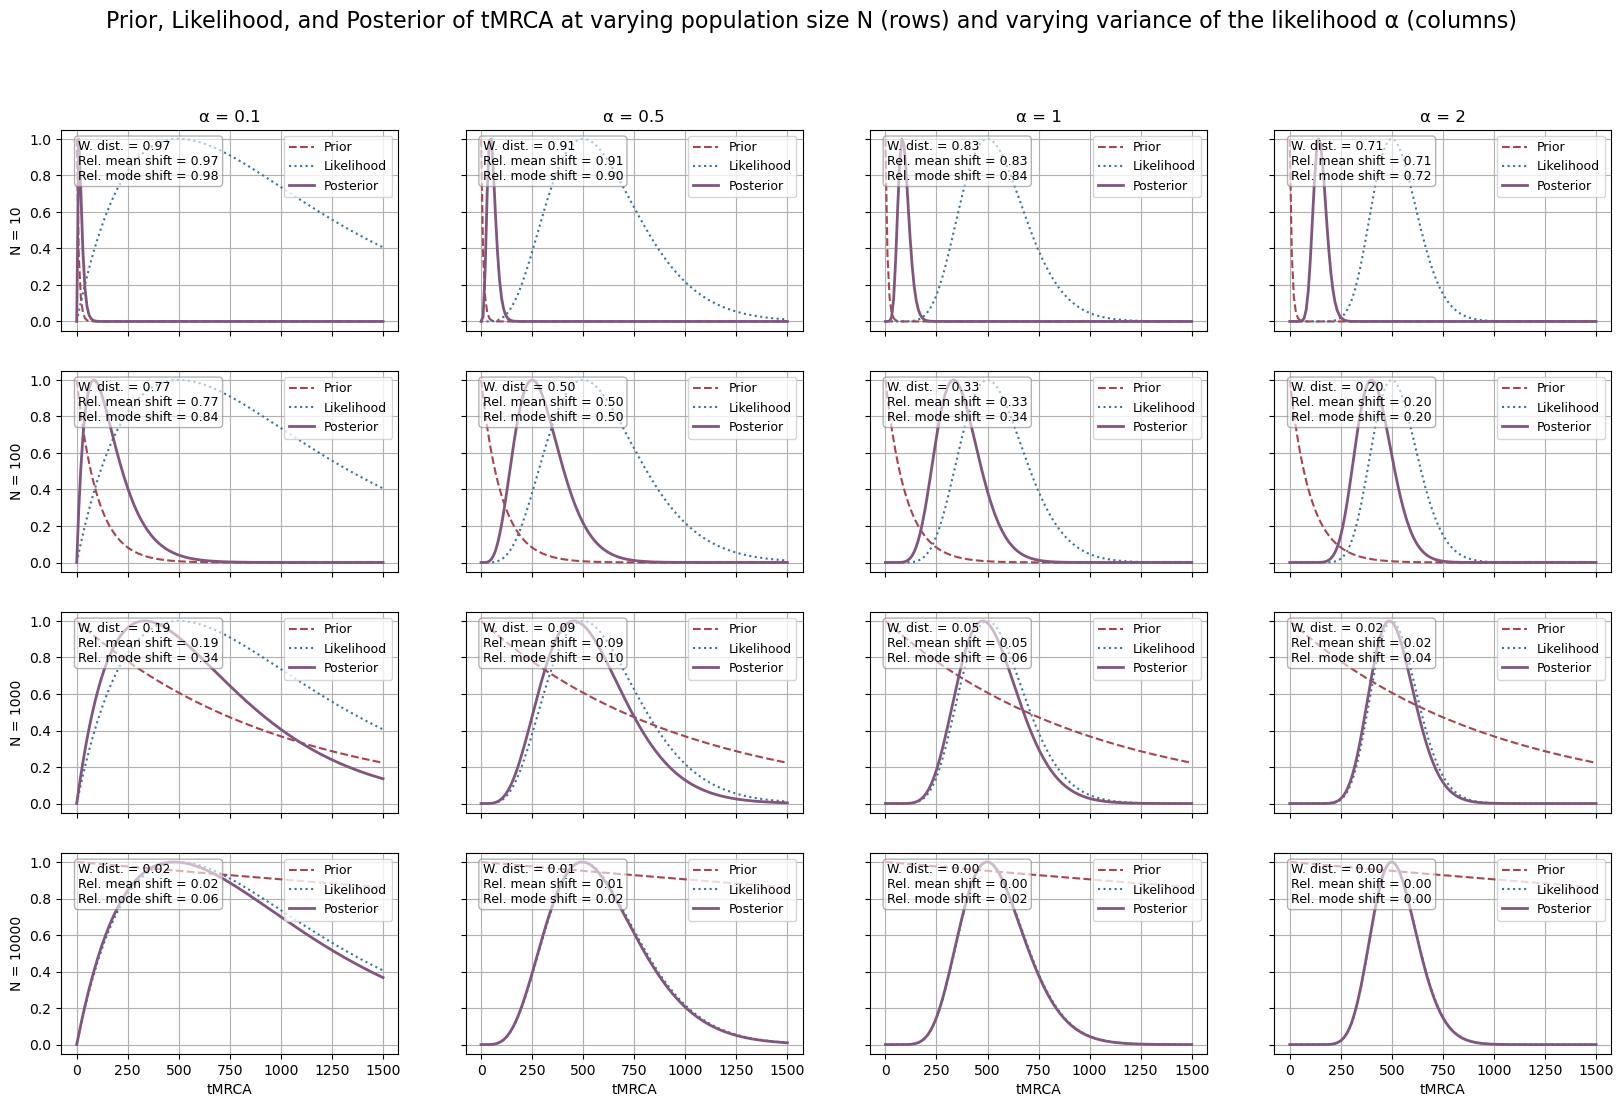

In [ ]:
# Setup parameters
L = 100
N_values = [10, 100, 1000, 10000]  # Rows
alpha_values = [0.1, 0.5, 1, 2]  # Columns
base_mu = 0.0001
base_k = 10
t_max = 1500  # Maximum tMRCA to consider

def plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L):
    """
    Plot the prior, likelihood, and posterior of tMRCA for varying population sizes and likelihood variances.
    
    Parameters:
    N_values (list): List of effective population sizes.
    alpha_values (list): List of variance multipliers for the likelihood.
    base_mu (float): Base mutation rate.
    base_k (int): Base number of mutations.
    t_values (np.array): Array of tMRCA values.
    L (int): Length of the genome in base pairs.
    """
    t_values = np.linspace(0, t_max, t_max//10)

    colors = [
        "#a6444f",  # Prior
        "#397398",  # Likelihood
        "#80557e",  # Posterior
    ]

    fig, axs = plt.subplots(len(N_values), len(alpha_values), figsize=(20, 12), sharex=True, sharey=True)

    for row, N in enumerate(N_values):
        for col, alpha in enumerate(alpha_values):
            mu = base_mu * alpha
            k_mut = int(base_k * alpha) if int(base_k * alpha) > 0 else 1  # ensure at least 1

            likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
            priors = np.array([coalescent_prior(t, N) for t in t_values])
            posteriors = likelihoods * priors

            # Normalize
            likelihoods /= np.max(likelihoods) if np.max(likelihoods) > 0 else 1
            priors /= np.max(priors) if np.max(priors) > 0 else 1
            posteriors /= np.max(posteriors) if np.max(posteriors) > 0 else 1

            ax = axs[row, col]
            ax.plot(t_values, priors, linestyle="--", color=colors[0], label="Prior")
            ax.plot(t_values, likelihoods, linestyle=":", color=colors[1], label="Likelihood")
            ax.plot(t_values, posteriors, linewidth=2, color=colors[2], label="Posterior")
            ax.grid(True)

            if row == len(N_values) - 1:
                ax.set_xlabel("tMRCA")
            if col == 0:
                ax.set_ylabel(f"N = {N}")
            if row == 0:
                ax.set_title(f"α = {alpha}")

            ax.legend(loc="upper right", fontsize=9)

            # Annotate normalized Wasserstein distance
            rel_w_dist = calculate_rel_wasserstein_dist(t_values, posteriors, likelihoods)
            rel_mean_shift = calculate_rel_mean_shift(t_values, posteriors, likelihoods)
            rel_mode_shift = calculate_rel_mode_shift(t_values, posteriors, likelihoods)
            ax.text(
                0.05, 0.95,
                f"W. dist. = {rel_w_dist:.2f}\nRel. mean shift = {rel_mean_shift:.2f}\nRel. mode shift = {rel_mode_shift:.2f}",
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.6)
            )



    #axs[0, 0].legend(loc="upper right", fontsize=9)
    plt.suptitle("Prior, Likelihood, and Posterior of tMRCA at varying population size N (rows) and varying variance of the likelihood α (columns)", fontsize=16)
    #plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L)

The values of the relative Wasserstein distance (relative to the expected tMRCA) show by how many units of what we expected the prior shifted the estimated posterior. For the high likelihood variance, low N case, the distance is close to 1 which suggests a full scale shift. For the low likelihood variance, high N case, the relative Wasserstein distance is 0.

Wasserstein distance and relative mean shift match, because we don't have strong shape differences but a shift.

## Extend to time-varying population size

Later this can be extended to models of varying population size, e.g. an exponentially growing population size $N(t) = N_0 \cdot e^{\beta t}$. This gives for the prior:
$$
P(t_{MRCA}|N) = \frac{1}{N_0} e^{-\beta(t_{\text{present}} - t_{MRCA})} \cdot e^{-\frac{1}{N_0 \cdot \beta} e^{-\beta t_{\text{present}}} \left( e^{\beta t_{MRCA}} - 1 \right)}
$$

The impact that the prior has on the posterior depends on the choice of $\beta$. For large beta (closer to 1), the prior shift the $t_{MRCA}$ back. For small $\beta$ (closer to 0), the prior decreases the expected $t_{MRCA}$. The following plot evaluates the impact that using a coalescent prior based on an exponentially growing population size has on the posterior likelihood.

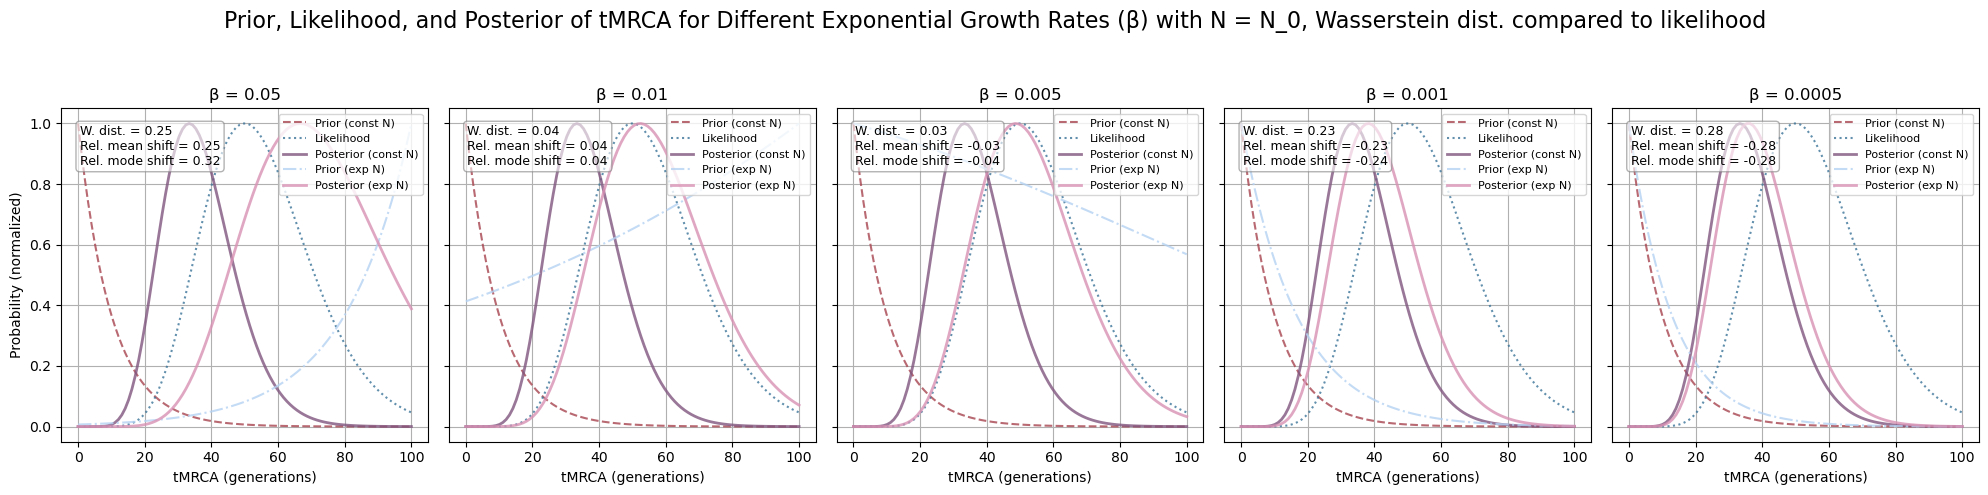

In [63]:
# Parameters
mu = 1e-3
L = 100
k_mut = 10
N = 10

t_present = 500
N_0 = 10
beta_vec = [0.05, 0.01, 0.005, 0.001, 0.0005]  # Columns
max_tmrca = 100  # Maximum tMRCA to consider

def plot_tMRCA_expN(mu, L, k_mut, t_present, N_0, beta_vec, max_tmrca, varying_N = False, N = None, N_vec = None, evaluation = 'likelihood'):
    """
    Plot the prior, likelihood, and posterior of tMRCA for different exponential growth rates (β).
    
    Parameters:
    mu (float): Mutation rate per base per generation.
    L (int): Length of the genome in base pairs.
    k_mut (int): Number of mutations observed.
    N (int): Effective population size.
    t_present (int): Present time point for exponential growth.
    N_0 (int): Initial population size for exponential growth.
    beta_vec (list): List of exponential growth rates.
    """
    

    t_values = np.linspace(0, max_tmrca, max_tmrca)

    colors = [
        "#a6444f",  # prior constant
        "#397398",  # likelihood
        "#80557e",  # posterior constant
        "#b5d2f2",  # prior expN
        "#d991b4",  # posterior expN
    ]

    # Set up subplots
    fig, axs = plt.subplots(1, len(beta_vec), figsize=(20, 5), sharey=True)

    for col, beta in enumerate(beta_vec):
        likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
        if varying_N:
            N_col = N_vec[col]
        else:
            N_col = N
        priors = np.array([coalescent_prior(t, N_col) for t in t_values])
        priors_expN = np.array([coalescent_prior_expN(t, N_0, beta, t_present) for t in t_values])
        
        posteriors = likelihoods * priors
        posteriors_expN = likelihoods * priors_expN

        # Normalize all for visualization
        likelihoods /= np.max(likelihoods)
        priors /= np.max(priors)
        posteriors /= np.max(posteriors)
        priors_expN /= np.max(priors_expN)
        posteriors_expN /= np.max(posteriors_expN)

        ax = axs[col]
        ax.plot(t_values, priors, label="Prior (const N)", linestyle="--", color=colors[0], alpha = 0.8)
        ax.plot(t_values, likelihoods, label="Likelihood", linestyle=":", color=colors[1], alpha = 0.8)
        ax.plot(t_values, posteriors, label="Posterior (const N)", linewidth=2, color=colors[2], alpha = 0.8)
        ax.plot(t_values, priors_expN, label="Prior (exp N)", linestyle="-.", color=colors[3], alpha = 0.8)
        ax.plot(t_values, posteriors_expN, label="Posterior (exp N)", linewidth=2, color=colors[4], alpha = 0.8)
        
        ax.set_title(f"β = {beta}, N = {N_col:.2f}" if varying_N else f"β = {beta}")

        ax.set_xlabel("tMRCA (generations)")
        if col == 0:
            ax.set_ylabel("Probability (normalized)")
        ax.grid(True)
        ax.legend(fontsize=8, loc="upper right")

        # Compares posterior based on exponential growth prior to likelihood (uniform prior)

        if evaluation == 'likelihood':
            rel_w_dist = calculate_rel_wasserstein_dist(t_values, posteriors_expN, likelihoods)
            rel_mean_shift = calculate_rel_mean_shift(t_values, posteriors_expN, likelihoods, abs_value=False)
            rel_mode_shift = calculate_rel_mode_shift(t_values, posteriors_expN, likelihoods, abs_value=False)
        elif evaluation == 'posterior_const_prior':
            rel_w_dist = calculate_rel_wasserstein_dist(t_values, posteriors_expN, posteriors)
            rel_mean_shift = calculate_rel_mean_shift(t_values, posteriors_expN, posteriors, abs_value=False)
            rel_mode_shift = calculate_rel_mode_shift(t_values, posteriors_expN, posteriors, abs_value=False)
        ax.text(
            0.05, 0.95,
            f"W. dist. = {rel_w_dist:.2f}\nRel. mean shift = {rel_mean_shift:.2f}\nRel. mode shift = {rel_mode_shift:.2f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.6)
        )

    N_text = "N_0" if not varying_N else "N_present"
    plt.suptitle(f"Prior, Likelihood, and Posterior of tMRCA for Different Exponential Growth Rates (β) with N = {N_text}, Wasserstein dist. compared to {evaluation}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

plot_tMRCA_expN(mu, L, k_mut, t_present, N_0, beta_vec, max_tmrca, N = N, varying_N=False)

Next, it would be interesting to compare the impact that a coalescent prior with exponentially growing population size has compared to a prior with constant population size.

Consider 2 scenarios:
- constant population size is the same as $N_0$
- constant population size is the same as $N(t_{present})$

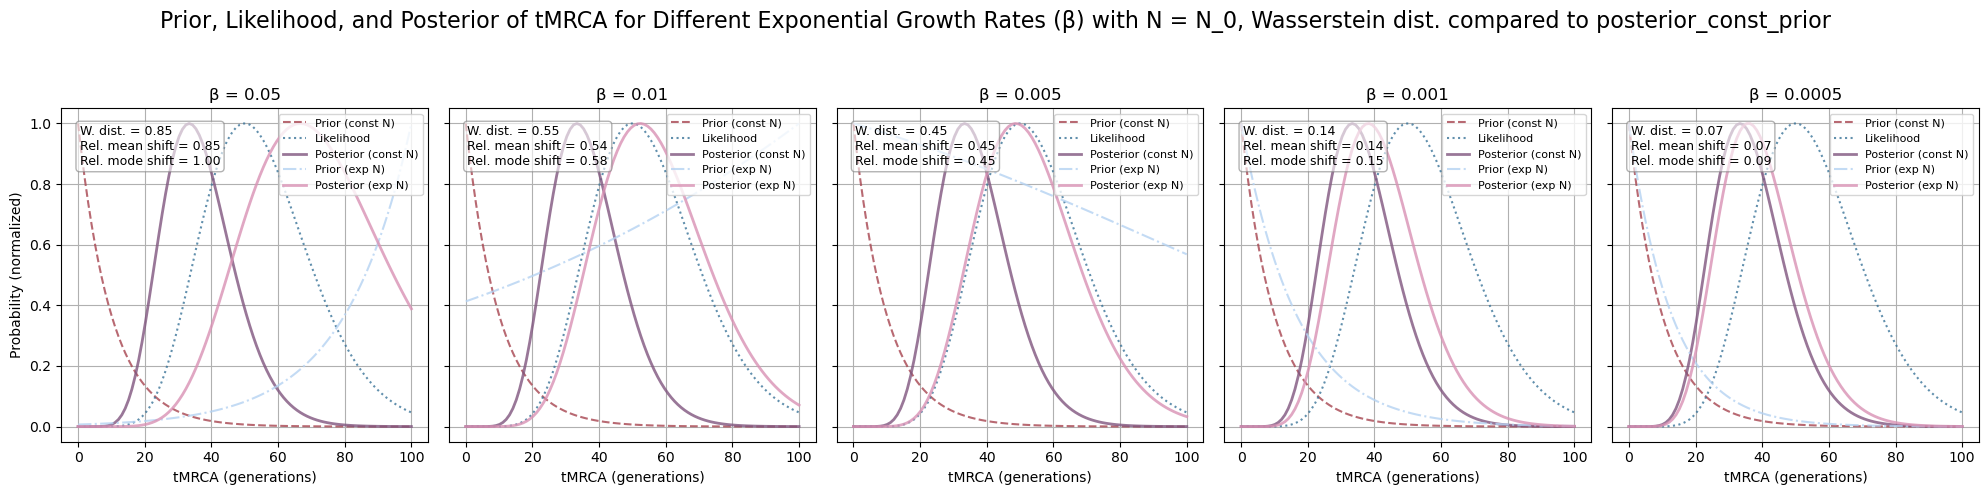

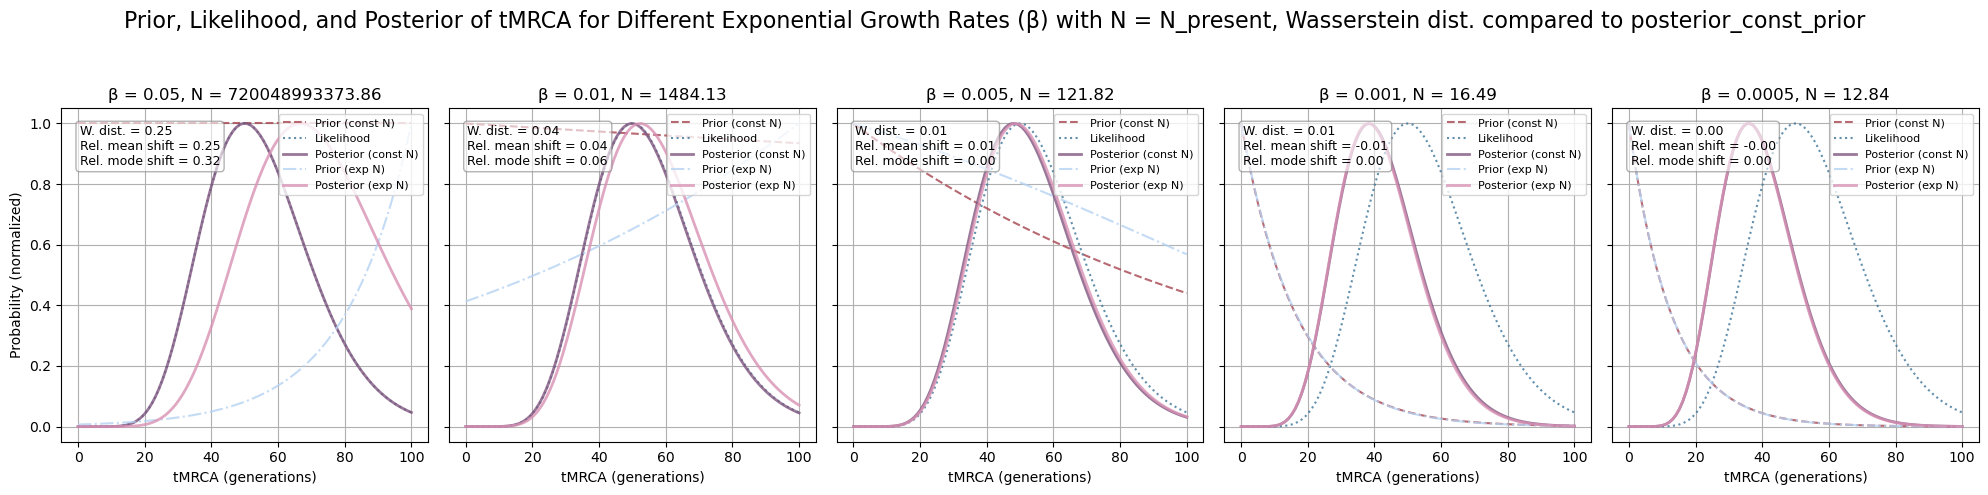

In [64]:
# Parameters
mu = 1e-3
L = 100
k_mut = 10

t_present = 500
N_0 = 10
beta_vec = np.array([0.05, 0.01, 0.005, 0.001, 0.0005])  # Columns
max_tmrca = 100  # Maximum tMRCA to consider

N = N_0
N_vec = N_0 * np.exp(beta_vec * t_present)

# case 1: N_const = N_0
plot_tMRCA_expN(mu, L, k_mut, t_present, N_0, beta_vec, max_tmrca, N = N, varying_N=False, evaluation='posterior_const_prior')
# case 2: N_const = N_present
plot_tMRCA_expN(mu, L, k_mut, t_present, N_0, beta_vec, max_tmrca, N_vec=N_vec, varying_N=True, evaluation='posterior_const_prior')

We also consider an exponentially declining population size.

Now, we want to consider a bottleneck.
$$
N(t_{\text{present}} - s) =
\begin{cases}
N_{\text{high}} & \text{if } s < \Delta t_{\text{bottleneck-start}} \text{ or } s > \Delta t_{\text{bottleneck-end}} \\
N_{\text{low}} & \text{if } \Delta t_{\text{bottleneck-start}} < s < \Delta t_{\text{bottleneck-end}}
\end{cases}
$$

This gives the following prior:
$$
P(t_{MRCA}|N(t))= 
\begin{cases}
\frac{1}{N_{\text{high}}} \cdot \exp\left(-\frac{t_{\text{MRCA}}}{N_{\text{high}}}\right)
& \text{if } t_{\text{MRCA}} < \Delta t_{\text{bottleneck-start}} \\[12pt]

\frac{1}{N_{\text{low}}} \cdot \exp\left( - \left( 
\frac{\Delta t_{\text{bottleneck-start}}}{N_{\text{high}}} 
+ \frac{t_{\text{MRCA}} - \Delta t_{\text{bottleneck-start}}}{N_{\text{low}}} 
\right) \right)
& \text{if } \Delta t_{\text{bottleneck-start}} < t_{\text{MRCA}} < \Delta t_{\text{bottleneck-end}} \\[12pt]

\frac{1}{N_{\text{high}}} \cdot \exp\left( - \left( 
\frac{\Delta t_{\text{bottleneck-start}}}{N_{\text{high}}} 
+ \frac{\Delta t_{\text{bottleneck-end}} - \Delta t_{\text{bottleneck-start}}}{N_{\text{low}}}
+ \frac{t_{\text{MRCA}} - \Delta t_{\text{bottleneck-end}}}{N_{\text{high}}}
\right) \right)
& \text{if } t_{\text{MRCA}} > \Delta t_{\text{bottleneck-end}}
\end{cases}
$$

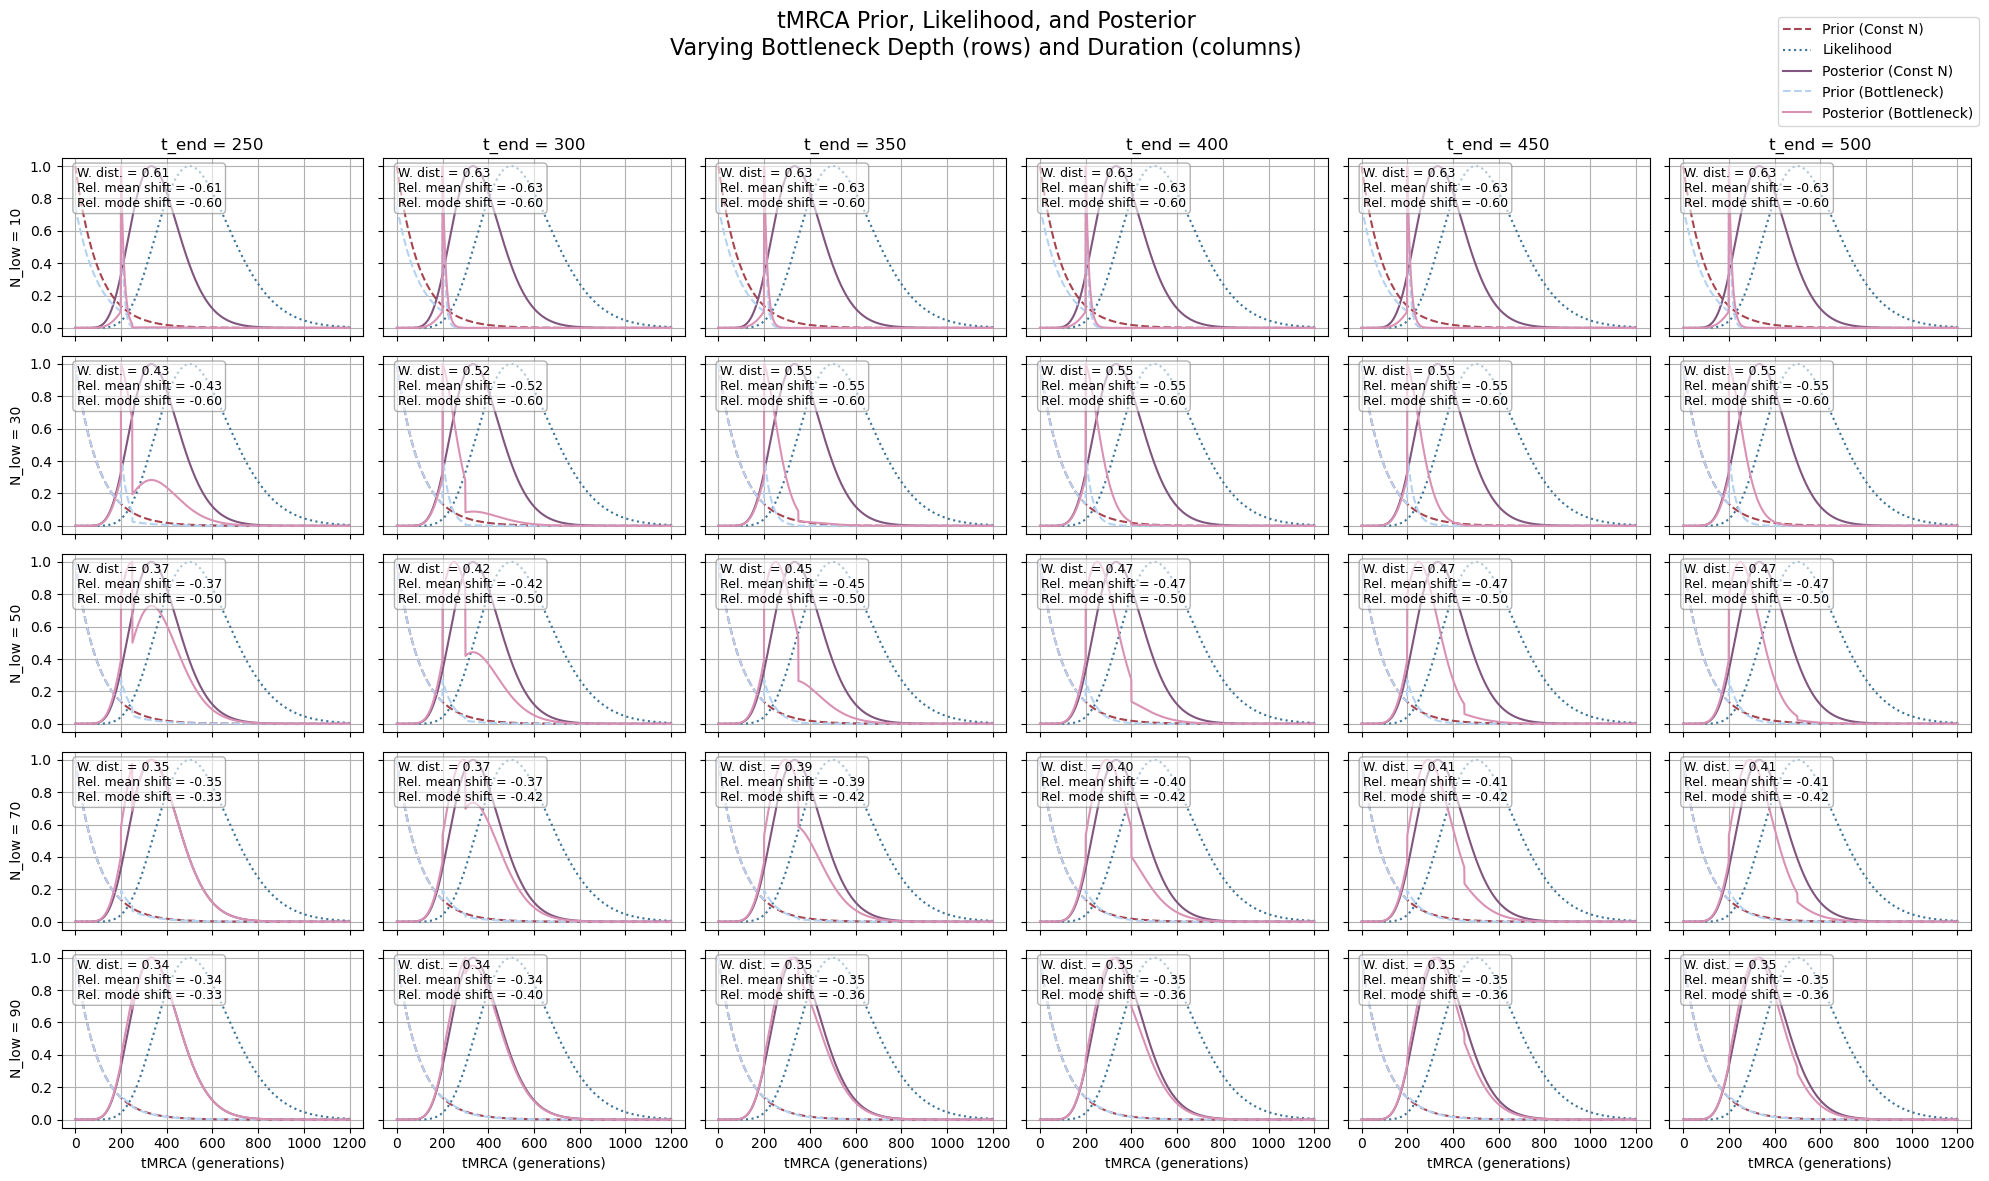

In [80]:

# === Parameters ===

L = 100
N = 100
mu = 0.0001
k_mut = 10
t_max = 1200

N_high = 100
t_bottleneck_start = 200

# Grid vectors
N_low_vec = [10, 30, 50, 70, 90]                    # Rows: bottleneck severity
t_bottleneck_end_vec = [250, 300, 350, 400, 450, 500]     # Columns: bottleneck duration

colors = ["#a6444f", "#397398", "#80557e", "#b5d2f2", "#d991b4"]

# === Subplot setup ===
def plot_tMRCA_bottleneck(mu, L, k_mut, N_high, N_low_vec, t_bottleneck_start, t_bottleneck_end_vec, t_max):
    """
    Plot the prior, likelihood, and posterior of tMRCA for varying bottleneck depths and durations.
    
    Parameters:
    mu (float): Mutation rate per base pair per generation.
    L (int): Length of the genome in base pairs.
    k_mut (int): Number of mutations observed.
    N_high (int): Population size before the bottleneck.
    N_low_vec (list): List of population sizes during the bottleneck.
    t_bottleneck_start (int): Start time of the bottleneck backwards in time.
    t_bottleneck_end_vec (list): List of end times for the bottleneck backwards in time.
    t_max (int): Maximum tMRCA to consider.
    """
    
    t_values = np.linspace(0, t_max, t_max)
    



    fig, axs = plt.subplots(len(N_low_vec), len(t_bottleneck_end_vec), figsize=(20, 12), sharex=True, sharey=True)

    for row, N_low in enumerate(N_low_vec):
        for col, t_bottleneck_end in enumerate(t_bottleneck_end_vec):
            
            likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
            priors = np.array([coalescent_prior(t, N) for t in t_values])
            priors_bottleneck = np.array([
                coalescent_prior_bottleneck(t, N_high, N_low, t_bottleneck_start, t_bottleneck_end)
                for t in t_values
            ])
            posteriors = likelihoods * priors
            posteriors_bottleneck = likelihoods * priors_bottleneck

            # Normalize for visualization
            likelihoods /= np.max(likelihoods)
            priors /= np.max(priors)
            posteriors /= np.max(posteriors)
            priors_bottleneck /= np.max(priors_bottleneck)
            posteriors_bottleneck /= np.max(posteriors_bottleneck)

            ax = axs[row, col]
            line1, = ax.plot(t_values, priors, linestyle="--", color=colors[0], label="Prior (Const N)")
            line2, = ax.plot(t_values, likelihoods, linestyle=":", color=colors[1], label="Likelihood")
            line3, = ax.plot(t_values, posteriors, color=colors[2], label="Posterior (Const N)")
            line4, = ax.plot(t_values, priors_bottleneck, linestyle="--", color=colors[3], label="Prior (Bottleneck)")
            line5, = ax.plot(t_values, posteriors_bottleneck, color=colors[4], label="Posterior (Bottleneck)")
            ax.grid(True)


            if row == len(N_low_vec) - 1:
                ax.set_xlabel("tMRCA (generations)")
            if col == 0:
                ax.set_ylabel(f"N_low = {N_low}")
            if row == 0:
                ax.set_title(f"t_end = {t_bottleneck_end}")

            rel_w_dist = calculate_rel_wasserstein_dist(t_values, posteriors_bottleneck, likelihoods)
            rel_mean_shift = calculate_rel_mean_shift(t_values, posteriors_bottleneck, likelihoods, abs_value=False)
            rel_mode_shift = calculate_rel_mode_shift(t_values, posteriors_bottleneck, likelihoods, abs_value=False)

            ax.text(
                0.05, 0.95,
                f"W. dist. = {rel_w_dist:.2f}\nRel. mean shift = {rel_mean_shift:.2f}\nRel. mode shift = {rel_mode_shift:.2f}",
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.6)
            )

            #if row == 0 and col == 0:
            #    ax.legend(fontsize=9, loc="upper right")

    # Final formatting
    fig.legend(
        handles=[line1, line2, line3, line4, line5],
        loc='upper right',
        bbox_to_anchor=(1, 0.98),
        fontsize=10
    )
    plt.suptitle("tMRCA Prior, Likelihood, and Posterior\nVarying Bottleneck Depth (rows) and Duration (columns)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

plot_tMRCA_bottleneck(mu, L, k_mut, N_high, N_low_vec, t_bottleneck_start, t_bottleneck_end_vec, t_max)

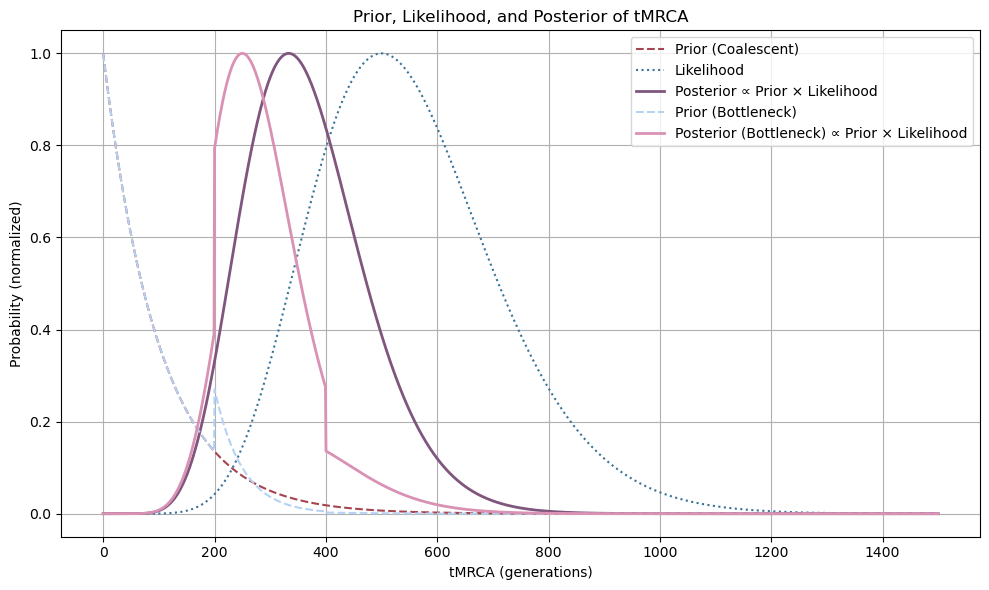

In [70]:
L = 100
N = 100
mu = 0.0001
k = 10
t_max = 1500  # Maximum tMRCA to consider
t_values = np.linspace(0, t_max, t_max)

N_high = 100
N_low = 50
t_bottleneck_start = 200
t_bottleneck_end = 400

# Compute values
likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
priors = np.array([coalescent_prior(t, N) for t in t_values])
priors_bottleneck = np.array([coalescent_prior_bottleneck(t, N_high, N_low, t_bottleneck_start, t_bottleneck_end) for t in t_values])
posteriors = likelihoods * priors
posteriors_bottleneck = likelihoods * priors_bottleneck

# Normalize for better visualization
likelihoods /= np.max(likelihoods)
priors /= np.max(priors)
posteriors /= np.max(posteriors)
priors_bottleneck /= np.max(priors_bottleneck)
posteriors_bottleneck /= np.max(posteriors_bottleneck)

colors = [
        "#a6444f",  # reddish
        "#397398",  # dark blue
        "#80557e",  # purple
        "#b5d2f2",  # light blue
        "#d991b4",  # pink
        "#57a8b8",  # teal
        "#7394c2",  # mid blue
        "#7a7a7a"   # gray
    ]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_values, priors, label="Prior (Coalescent)", linestyle="--", color = colors[0])
plt.plot(t_values, likelihoods, label="Likelihood", linestyle=":", color = colors[1])
plt.plot(t_values, posteriors, label="Posterior ∝ Prior × Likelihood", linewidth=2, color = colors[2])
plt.plot(t_values, priors_bottleneck, label="Prior (Bottleneck)", linestyle="--", color = colors[3])
plt.plot(t_values, posteriors_bottleneck, label="Posterior (Bottleneck) ∝ Prior × Likelihood", linewidth=2, color = colors[4])
plt.xlabel("tMRCA (generations)")
plt.ylabel("Probability (normalized)")
plt.title("Prior, Likelihood, and Posterior of tMRCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# The curves don't overlap in the start because of normalization

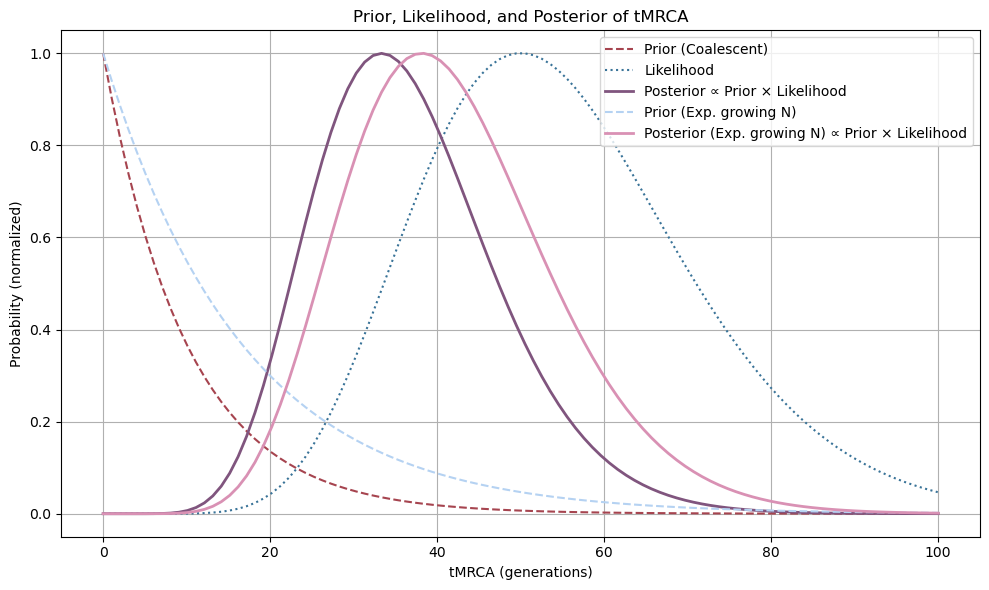

In [25]:
# Parameters
mu = 1e-3        # mutation rate per base per generation
L = 100          # genome length
k_mut = 10        # observed mutations
N = 10         # effective population size

t_present = 500
beta = 0.001
N_0 = 10

# Time grid
t_values = np.linspace(0, 100, 100)

# Compute values
likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
priors = np.array([coalescent_prior(t, N) for t in t_values])
priors_expN = np.array([coalescent_prior_expN(t, N_0, beta, t_present) for t in t_values])
posteriors = likelihoods * priors
posteriors_expN = likelihoods * priors_expN

# Normalize for better visualization
likelihoods /= np.max(likelihoods)
priors /= np.max(priors)
posteriors /= np.max(posteriors)
priors_expN /= np.max(priors_expN)
posteriors_expN /= np.max(posteriors_expN)

colors = [
        "#a6444f",  # reddish
        "#397398",  # dark blue
        "#80557e",  # purple
        "#b5d2f2",  # light blue
        "#d991b4",  # pink
        "#57a8b8",  # teal
        "#7394c2",  # mid blue
        "#7a7a7a"   # gray
    ]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_values, priors, label="Prior (Coalescent)", linestyle="--", color = colors[0])
plt.plot(t_values, likelihoods, label="Likelihood", linestyle=":", color = colors[1])
plt.plot(t_values, posteriors, label="Posterior ∝ Prior × Likelihood", linewidth=2, color = colors[2])
plt.plot(t_values, priors_expN, label="Prior (Exp. growing N)", linestyle="--", color = colors[3])
plt.plot(t_values, posteriors_expN, label="Posterior (Exp. growing N) ∝ Prior × Likelihood", linewidth=2, color = colors[4])
plt.xlabel("tMRCA (generations)")
plt.ylabel("Probability (normalized)")
plt.title("Prior, Likelihood, and Posterior of tMRCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()